In [1]:
# Install required libraries
import subprocess
subprocess.run(["pip", "install", "scikit-learn", "pandas", "matplotlib", "seaborn", "wordcloud"], check=True)
print("All libraries installed!")

All libraries installed!


Dataset loaded: 5572 messages | ham=4825 | spam=747
Train: 4457 | Test: 1115

===== ALL RESULTS =====
Feature          Classifier  Accuracy  Precision  Recall  F1-Score
    BoW         Naive Bayes     98.39      96.45   91.28     93.79
    BoW Logistic Regression     97.49      99.19   81.88     89.71
    BoW                 SVM     98.21      99.24   87.25     92.86
    BoW       Random Forest     97.31     100.00   79.87     88.81
 TF-IDF         Naive Bayes     96.95     100.00   77.18     87.12
 TF-IDF Logistic Regression     96.68     100.00   75.17     85.82
 TF-IDF                 SVM     98.21      98.50   87.92     92.91
 TF-IDF       Random Forest     97.40     100.00   80.54     89.22


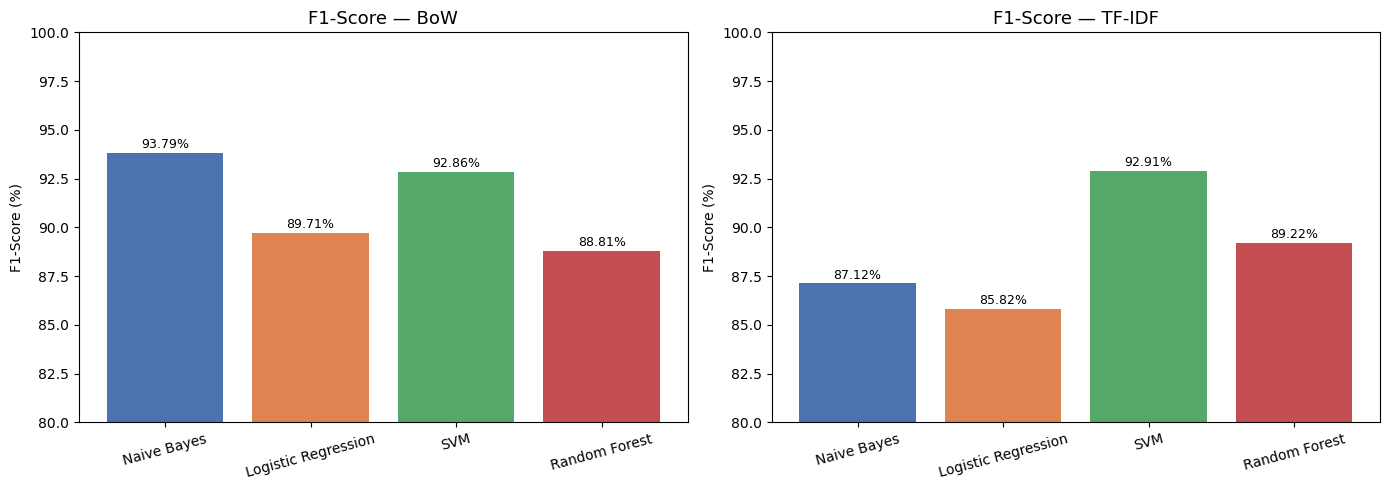

Saved: f1_comparison.png

Best model: Naive Bayes with BoW — F1=93.79%


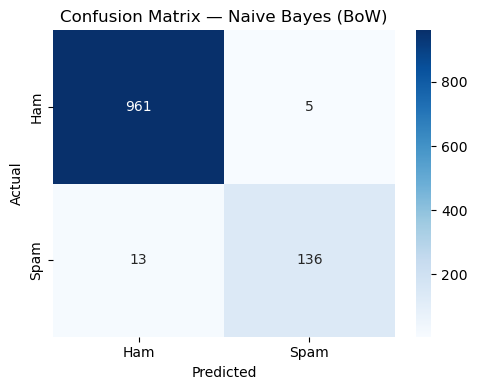

Saved: confusion_matrix.png

✅ All done! Copy the results table into your Word doc.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load data ──────────────────────────────────────────
df = pd.read_csv('email.csv')
df = df[df['Category'].isin(['ham','spam'])].copy()
df['label'] = (df['Category'] == 'spam').astype(int)
print(f"Dataset loaded: {len(df)} messages | ham={sum(df.label==0)} | spam={sum(df.label==1)}")

# ── 2. Train/test split ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    df['Message'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── 3. Feature extractors ─────────────────────────────────
vectorizers = {
    'BoW':   CountVectorizer(stop_words='english'),
    'TF-IDF': TfidfVectorizer(stop_words='english')
}

# ── 4. Classifiers ────────────────────────────────────────
classifiers = {
    'Naive Bayes':        MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM':                LinearSVC(),
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42)
}

# ── 5. Run all experiments ────────────────────────────────
results = []
for vec_name, vec in vectorizers.items():
    X_tr = vec.fit_transform(X_train)
    X_te = vec.transform(X_test)
    for clf_name, clf in classifiers.items():
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)
        results.append({
            'Feature':    vec_name,
            'Classifier': clf_name,
            'Accuracy':   round(accuracy_score(y_test, y_pred)*100, 2),
            'Precision':  round(precision_score(y_test, y_pred)*100, 2),
            'Recall':     round(recall_score(y_test, y_pred)*100, 2),
            'F1-Score':   round(f1_score(y_test, y_pred)*100, 2),
        })

results_df = pd.DataFrame(results)
print("\n===== ALL RESULTS =====")
print(results_df.to_string(index=False))

# ── 6. Bar chart — F1 Score comparison ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (feat, grp) in enumerate(results_df.groupby('Feature')):
    axes[i].bar(grp['Classifier'], grp['F1-Score'], color=['#4C72B0','#DD8452','#55A868','#C44E52'])
    axes[i].set_title(f'F1-Score — {feat}', fontsize=13)
    axes[i].set_ylabel('F1-Score (%)')
    axes[i].set_ylim(80, 100)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(axes[i].patches, grp['F1-Score']):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                     f'{val}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150)
plt.show()
print("Saved: f1_comparison.png")

# ── 7. Confusion matrix for best model ───────────────────
best = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"\nBest model: {best['Classifier']} with {best['Feature']} — F1={best['F1-Score']}%")

vec  = vectorizers[best['Feature']]
# refit on train (already fitted above, just re-transform)
X_tr = vec.fit_transform(X_train)
X_te = vec.transform(X_test)
clf  = classifiers[best['Classifier']]
clf.fit(X_tr, y_train)
cm   = confusion_matrix(y_test, clf.predict(X_te))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.title(f'Confusion Matrix — {best["Classifier"]} ({best["Feature"]})')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()d
print("Saved: confusion_matrix.png")

print("\n✅ All done! Copy the results table into your Word doc.")